7. Exploratory Data Analysis and visualization for given data set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

In [2]:
df = pd.read_csv('CSV/location.csv')

In [10]:
print("First 5 rows of datasets: \n")
df.head()

First 5 rows of datasets: 



,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [12]:
print("\nData Info:\n")
print(df.info())


Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB
None


In [5]:
print("Summary of Dataset: \n")
df.describe()

Summary of Dataset: 



,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [8]:
print("Data Types of columns: \n")
print(df.dtypes)

Data Types of columns: 

Unnamed: 0.1      int64
Unnamed: 0        int64
Text             object
Sentiment        object
Timestamp        object
User             object
Platform         object
Hashtags         object
Retweets        float64
Likes           float64
Country          object
Year              int64
Month             int64
Day               int64
Hour              int64
dtype: object


In [9]:
print("Missing values (if any): \n")
print(df.isnull().sum())

Missing values (if any): 

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [13]:
numeric_cols = df.select_dtypes(['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

print("Correlation matrix: \n")
print(corr_matrix)

Correlation matrix: 

              Unnamed: 0.1  Unnamed: 0  Retweets     Likes      Year  \
Unnamed: 0.1      1.000000    0.999995  0.388637  0.376208  0.101578   
Unnamed: 0        0.999995    1.000000  0.388884  0.376472  0.100749   
Retweets          0.388637    0.388884  1.000000  0.998482 -0.039982   
Likes             0.376208    0.376472  0.998482  1.000000 -0.043415   
Year              0.101578    0.100749 -0.039982 -0.043415  1.000000   
Month             0.443013    0.443523  0.073265  0.066643 -0.314845   
Day              -0.080101   -0.080480  0.009213  0.011489  0.021973   
Hour              0.322371    0.322163  0.196955  0.195331 -0.087470   

                 Month       Day      Hour  
Unnamed: 0.1  0.443013 -0.080101  0.322371  
Unnamed: 0    0.443523 -0.080480  0.322163  
Retweets      0.073265  0.009213  0.196955  
Likes         0.066643  0.011489  0.195331  
Year         -0.314845  0.021973 -0.087470  
Month         1.000000 -0.135873  0.137835  
Day          -

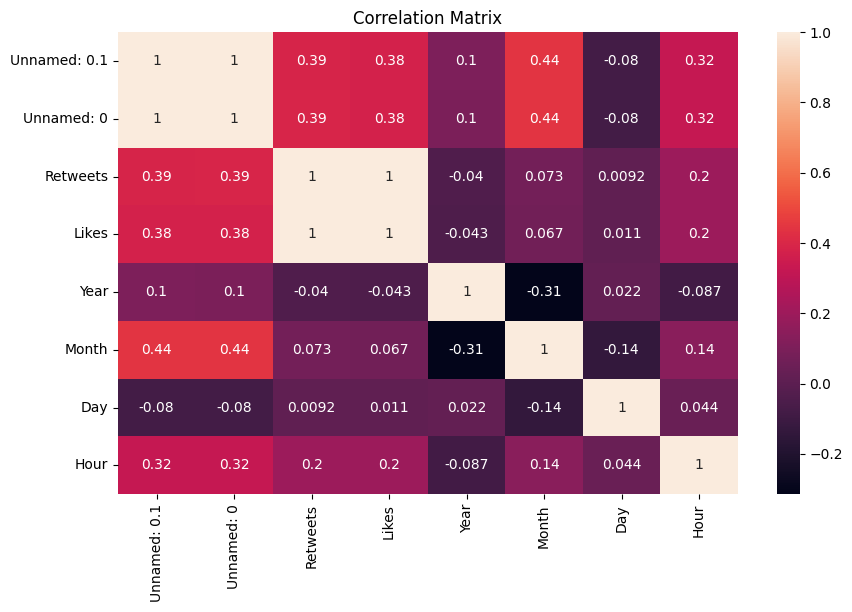

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

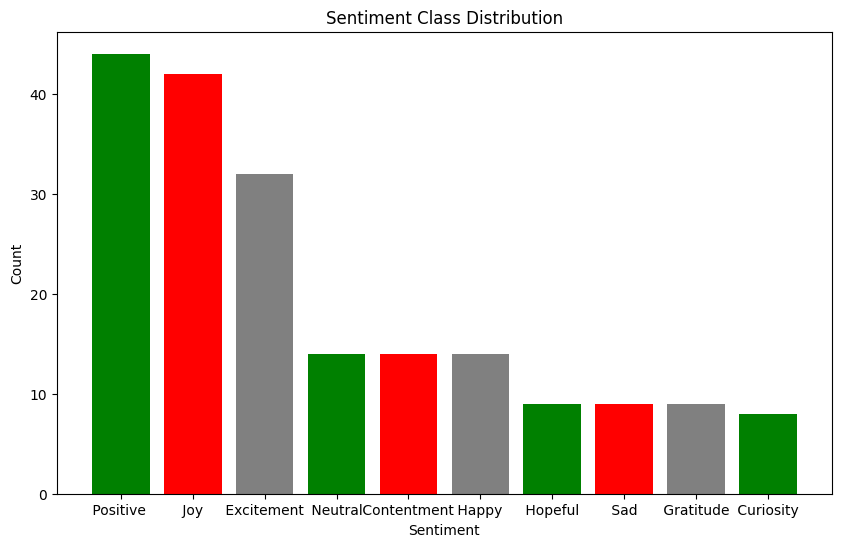

In [27]:
sentiment_ctr = df['Sentiment'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.bar(sentiment_ctr.index, sentiment_ctr.values, color=['green', 'red', 'gray'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Text(0, 0.5, 'Frequency')

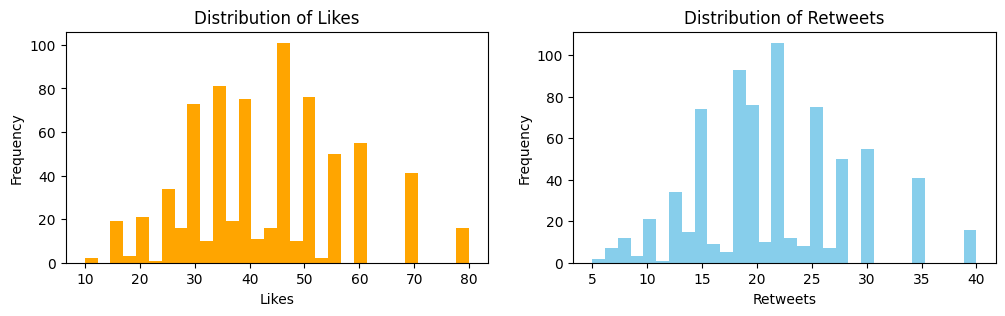

In [30]:
plt.figure(figsize=(12 ,3))

plt.subplot(1, 2, 1)
plt.hist(df['Likes'].dropna(), color=['orange'], bins=30)
plt.title('Distribution of Likes')
plt.xlabel('Likes')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['Retweets'].dropna(), color=['skyblue'], bins=30)
plt.title('Distribution of Retweets')
plt.xlabel('Retweets')
plt.ylabel('Frequency')

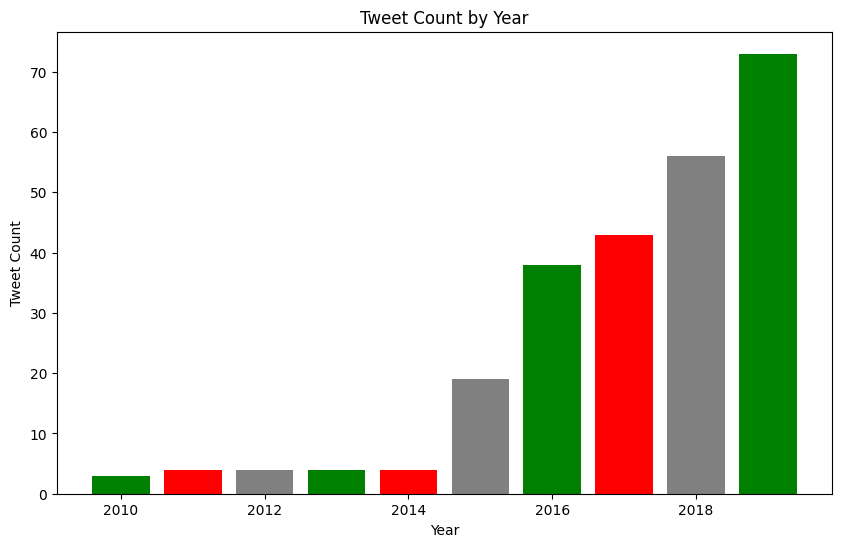

In [25]:
year_ctr = df['Year'].value_counts().sort_index().head(10)
plt.figure(figsize=(10, 6))
plt.bar(year_ctr.index, year_ctr.values, color=['green', 'red', 'gray'])
plt.title('Tweet Count by Year')
plt.xlabel('Year')
plt.ylabel('Tweet Count')
plt.show()

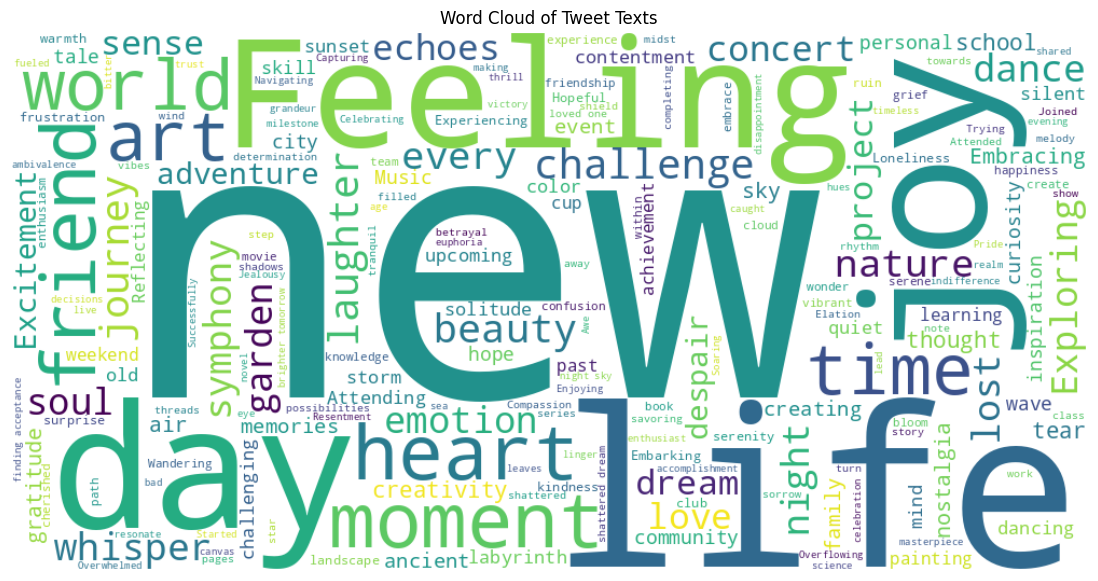

In [26]:
all_text = ' '.join(df['Text'].dropna().tolist())
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Tweet Texts")
plt.show()